In [3]:
import pandas as pd
import matplotlib as plt
import matplotlib.pyplot as ppt 
import seaborn as sns

df = pd.read_csv(r"C:\Users\1\Documents\DZ\data_science\data\Bank Customer Churn Prediction.csv")
print(df.shape) # строки, столбцы
print(df.info()) # ntn
print(df.describe()) # ntn

(10000, 12)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB
None
        customer_id  credit_score           age        tenure        balance  \
count  1.000000e+04  10000.000000  10000.000000  10000.000000   10000.000000   
mean   1

churn
0    0.8
1    0.2
Name: proportion, dtype: float64


([<matplotlib.axis.XTick at 0x227482a6490>,
 [Text(0, 0, 'Остался'), Text(1, 0, 'Ушел')])

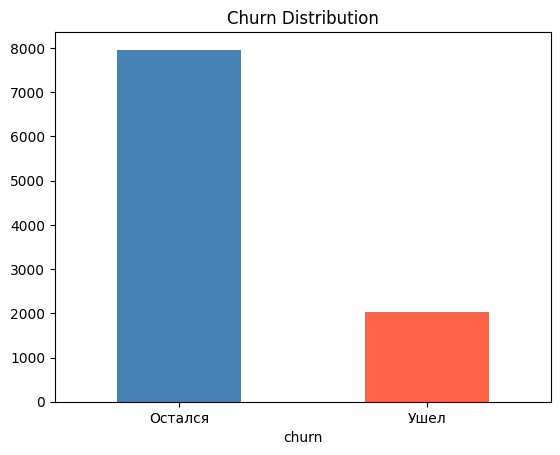

In [6]:
#print(df.isnull().sum())
#print("Дубликаты:", df.duplicated().sum()) # how it works??
print(df['churn'].value_counts(normalize=True).round(2)) # э
df['churn'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
ppt.title('Churn Distribution')
ppt.xticks([0, 1], ['Остался', 'Ушел'], rotation=0) # подписи делений икса
# сейчас мы оценили распределение целевой переменной

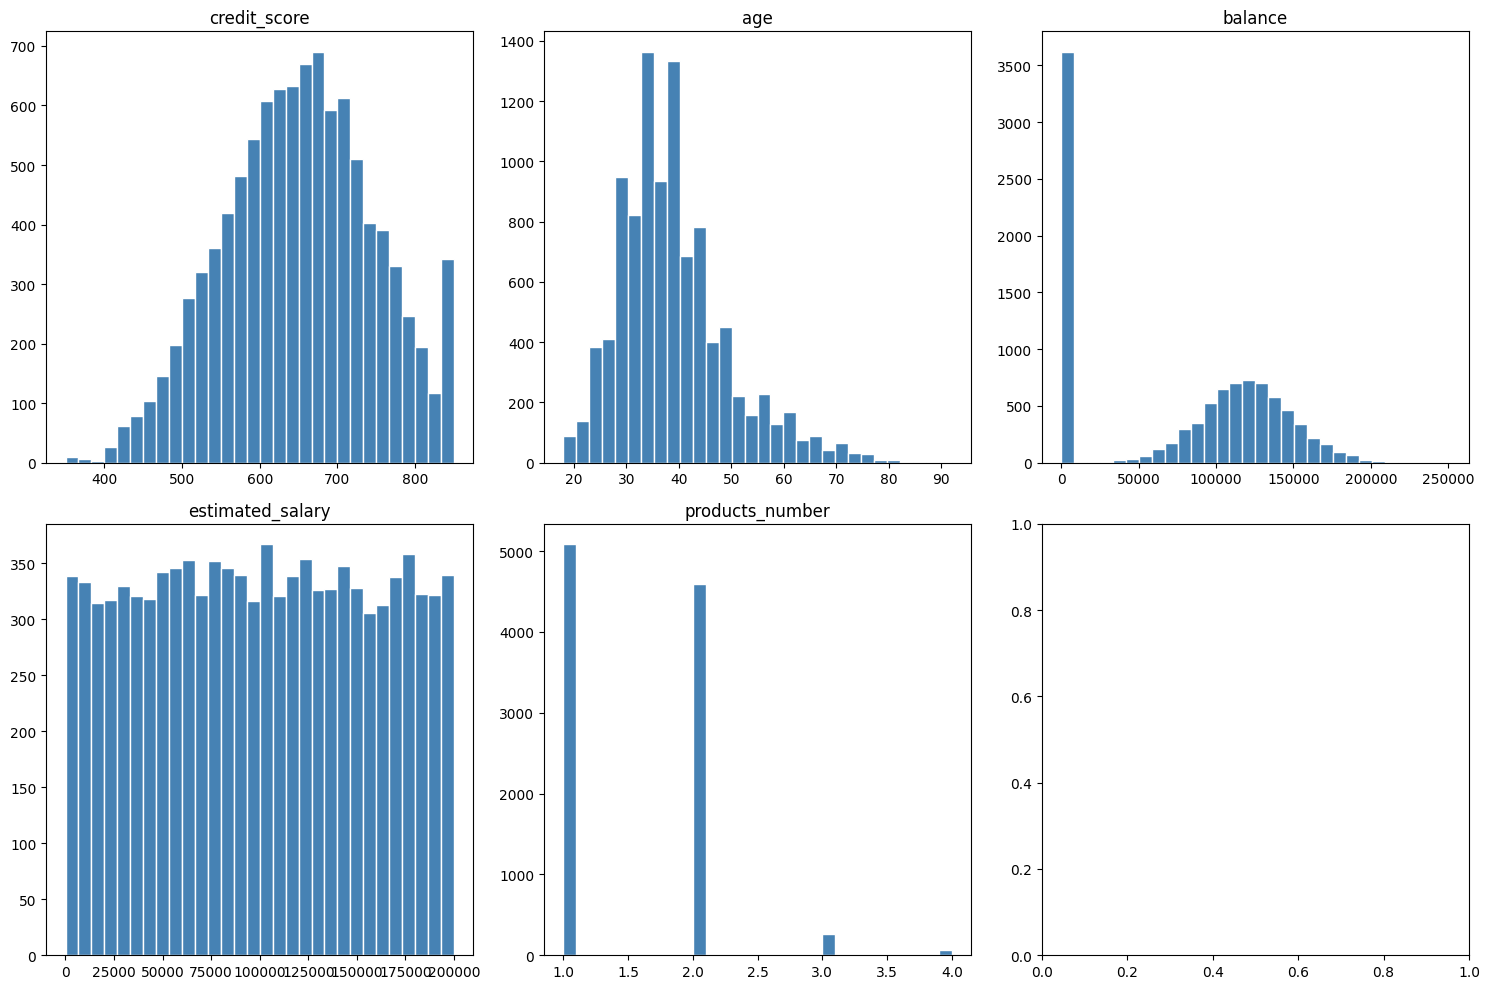

In [7]:
# визуальная оценка распределений числовых признаков

num_cols = ['credit_score', 'age', 'balance', 'estimated_salary', 'products_number'] # набор количественных признаков
fig, axes = ppt.subplots(2, 3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col)
ppt.tight_layout()

In [37]:
# отток по категориальным признакам
for col in ['gender', 'country', 'credit_card', 'active_member']:
    print(df.groupby(col)['churn'].mean().round(2))

gender
Female    0.25
Male      0.16
Name: churn, dtype: float64
country
France     0.16
Germany    0.32
Spain      0.17
Name: churn, dtype: float64
credit_card
0    0.21
1    0.20
Name: churn, dtype: float64
active_member
0    0.27
1    0.14
Name: churn, dtype: float64


Text(0.5, 1.0, 'Correlation matrix')

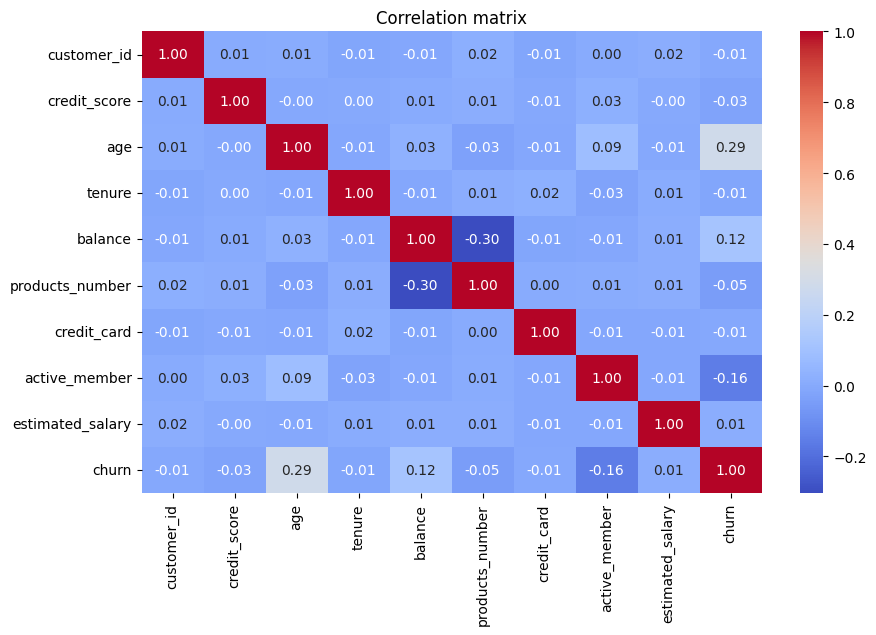

In [8]:
ppt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include='number').corr(),
           annot=True, fmt='.2f', cmap='coolwarm')
ppt.title('Correlation matrix')

Text(0.5, 1.0, 'age vs ottok')

<Figure size 800x400 with 0 Axes>

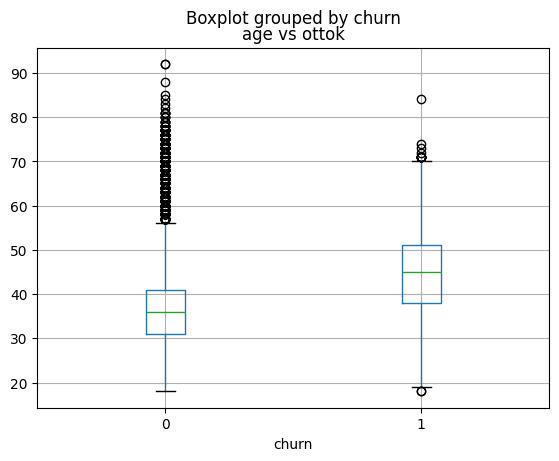

In [9]:
ppt.figure(figsize=(8, 4))
df.boxplot(column='age', by='churn')
ppt.title('age vs ottok')

Text(0.5, 1.0, 'Balance vs ottok')

<Figure size 800x400 with 0 Axes>

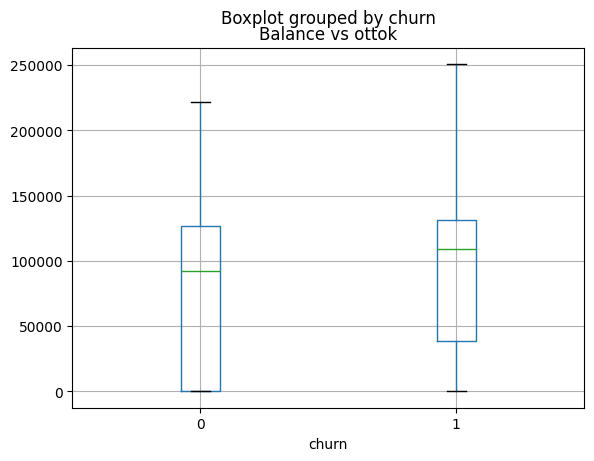

In [10]:
ppt.figure(figsize=(8, 4))
df.boxplot(column='balance', by='churn')
ppt.title('Balance vs ottok')

Text(0.5, 1.0, 'active_member vs ottok')

<Figure size 800x400 with 0 Axes>

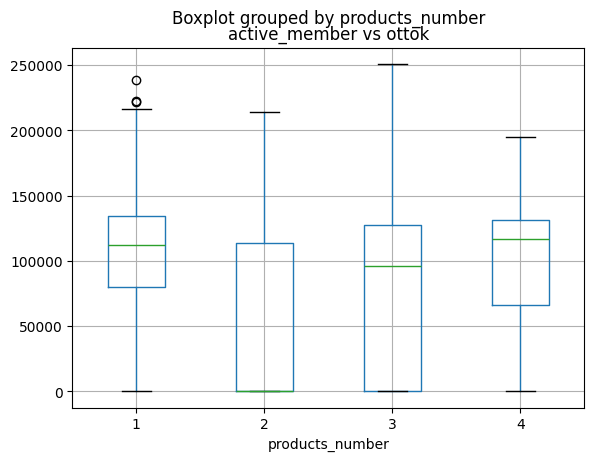

In [11]:
ppt.figure(figsize=(8, 4))
df.boxplot(column='balance', by='products_number')
ppt.title('active_member vs ottok')